In [1]:
import kagglehub

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Path to dataset files:", path)

100%|██████████| 368k/368k [00:01<00:00, 318kB/s]

Extracting files...
Path to dataset files: C:\Users\acer\.cache\kagglehub\datasets\laotse\credit-risk-dataset\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


In [3]:
import kagglehub

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
files = os.listdir(path)
print("Files:", files)

df_credit = pd.read_csv(path + '/' + files[0])
print("Shape:", df_credit.shape)
df_credit.head()

Files: ['credit_risk_dataset.csv']
Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
print(df_credit.info())
print("\n")
print(df_credit.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


         person_age  per

In [5]:
print("Missing values:")
print(df_credit.isnull().sum())

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


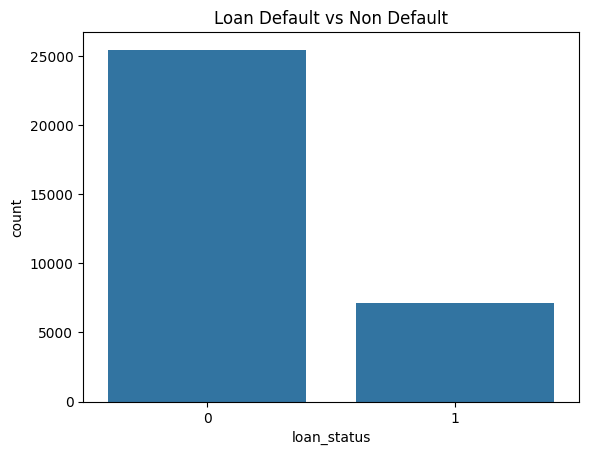

In [6]:
print("Target distribution:")
print(df_credit['loan_status'].value_counts())

sns.countplot(x='loan_status', data=df_credit)
plt.title('Loan Default vs Non Default')
plt.show()

In [7]:
# Fill employment length with median
df_credit['person_emp_length'].fillna(df_credit['person_emp_length'].median(), inplace=True)

# Fill interest rate with median
df_credit['loan_int_rate'].fillna(df_credit['loan_int_rate'].median(), inplace=True)

print("Missing values after fixing:")
print(df_credit.isnull().sum())

Missing values after fixing:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


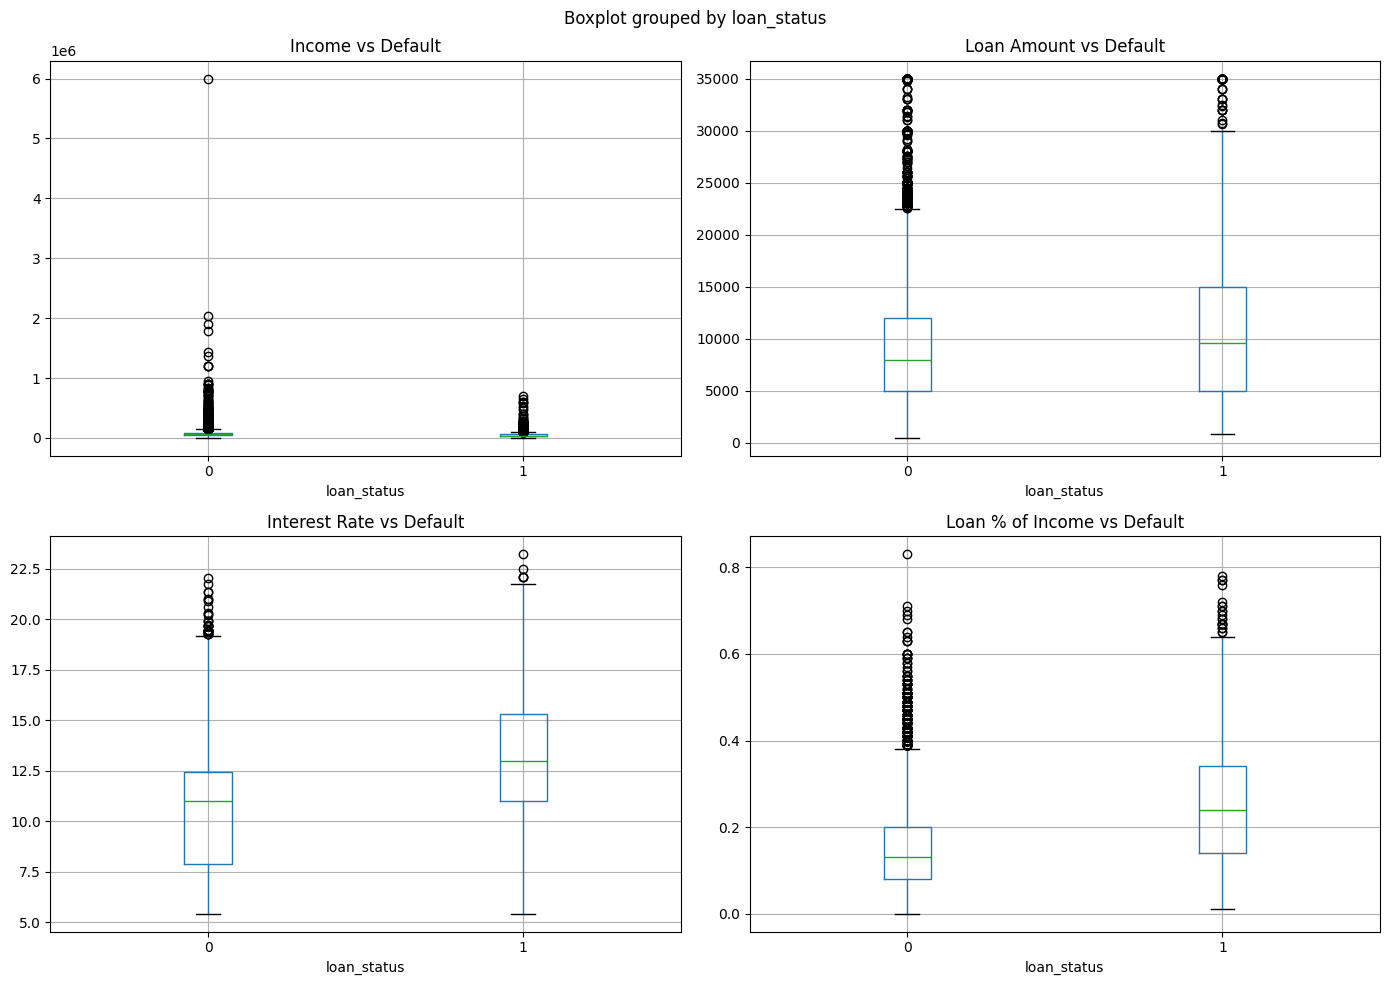

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income vs Default
df_credit.boxplot(column='person_income', by='loan_status', ax=axes[0,0])
axes[0,0].set_title('Income vs Default')

# Loan Amount vs Default
df_credit.boxplot(column='loan_amnt', by='loan_status', ax=axes[0,1])
axes[0,1].set_title('Loan Amount vs Default')

# Interest Rate vs Default
df_credit.boxplot(column='loan_int_rate', by='loan_status', ax=axes[1,0])
axes[1,0].set_title('Interest Rate vs Default')

# Loan Percent Income vs Default
df_credit.boxplot(column='loan_percent_income', by='loan_status', ax=axes[1,1])
axes[1,1].set_title('Loan % of Income vs Default')

plt.tight_layout()
plt.show()

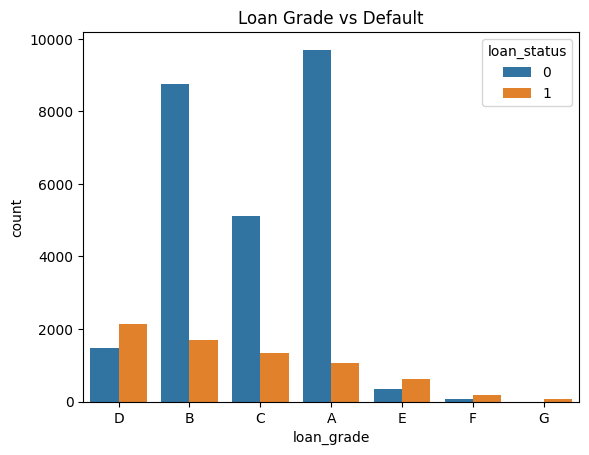

In [9]:
sns.countplot(x='loan_grade', hue='loan_status', data=df_credit)
plt.title('Loan Grade vs Default')
plt.show()

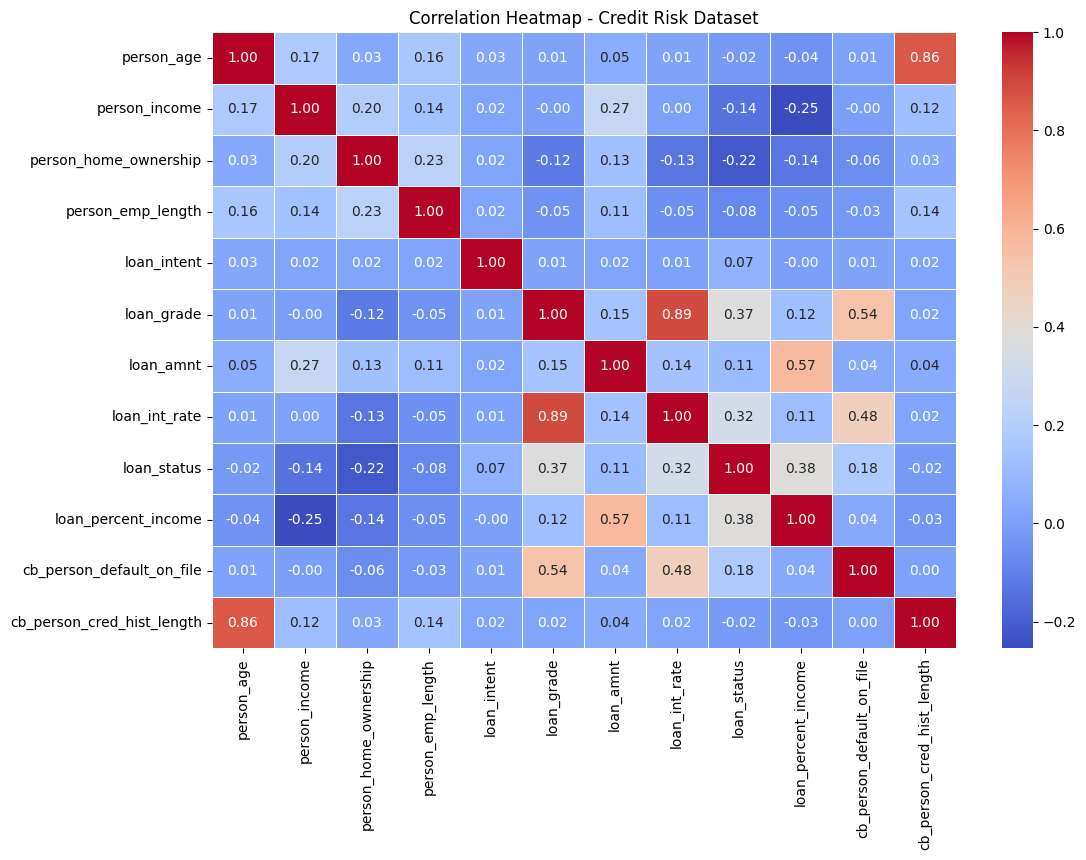

In [10]:
# Convert categorical columns to numbers first
df_credit_encoded = df_credit.copy()

df_credit_encoded['person_home_ownership'] = df_credit_encoded['person_home_ownership'].map(
    {'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3}
)

df_credit_encoded['loan_intent'] = df_credit_encoded['loan_intent'].map(
    {'PERSONAL': 0, 'EDUCATION': 1, 'MEDICAL': 2, 
     'VENTURE': 3, 'HOMEIMPROVEMENT': 4, 'DEBTCONSOLIDATION': 5}
)

df_credit_encoded['loan_grade'] = df_credit_encoded['loan_grade'].map(
    {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
)

df_credit_encoded['cb_person_default_on_file'] = df_credit_encoded['cb_person_default_on_file'].map(
    {'N': 0, 'Y': 1}
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_credit_encoded.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Credit Risk Dataset')
plt.show()

In [11]:
df_credit_encoded.to_csv('credit_risk_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
